In [1]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow_hub as hub
import random
import os

os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.models import Sequential
from keras.layers import Dense, LSTM, SimpleRNN, Embedding
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [2]:
def set_deterministic_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_deterministic_seed(42)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
df = pd.read_csv("/content/drive/MyDrive/nlp/MovieReviewTrainingDatabase.csv")
df.shape

(25000, 2)

In [5]:
df.head()

,sentiment,review
0,Positive,With all this stuff going down at the moment w...
1,Positive,'The Classic War of the Worlds' by Timothy Hin...
2,Negative,The film starts with a manager (Nicholas Bell)...
3,Negative,It must be assumed that those who praised this...
4,Positive,Superbly trashy and wondrously unpretentious 8...


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  25000 non-null  object
 1   review     25000 non-null  object
dtypes: object(2)
memory usage: 390.8+ KB


In [7]:
# Stripping the columns of any spaces in them to avoid errors
df.columns = df.columns.str.strip().str.replace('  ', ' ', regex=False)

In [8]:
# Checking for missing values
df.isnull().sum()

,0
sentiment,0
review,0


In [9]:
# Checking for duplicates
df.duplicated().sum()

np.int64(96)

In [10]:
# dropping the duplicates from the dataframe
df = df.drop_duplicates()

In [11]:
# creating a processing function to help process our reviews
def preprocess(data):
    # Changing all the review message to lower case
    data = data.str.lower()
    # Removing punctuations from the review message
    data = data.apply(lambda x: re.sub(r"[^\w\s]", '', x))
    # replace digits with no space
    data = data.apply(lambda x: re.sub(r"\d", '', x))
    # Tokenization
    data = data.str.split()
    nltk.download("stopwords")
    stop_words = set(stopwords.words("english"))
    data = data.apply(lambda x: [word for word in x if word not in stop_words])

    return data

In [12]:
# Defining X and Y
X = preprocess(df["review"])
# Encoding the Sentiment Values (Positive & Negative) to a binary value (1 & 0)
encoder = LabelEncoder()
Y = encoder.fit_transform(df["sentiment"])
print(f"Shape of y (Labels): {Y.shape}")
Y

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Shape of y (Labels): (24904,)


array([1, 1, 0, ..., 0, 0, 1])

# **Checking class Imbalance**

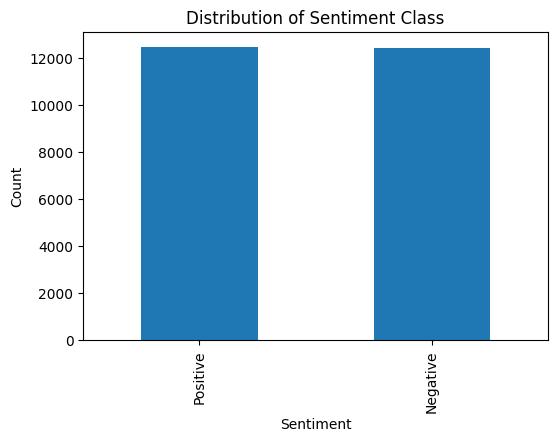

In [13]:
plt.figure(figsize=(6, 4))
df["sentiment"].value_counts().plot(kind="bar")
plt.title('Distribution of Sentiment Class')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

In [14]:
# Getting pre_embedded model stored inside the dict (embeddings)
glove = "/content/drive/MyDrive/nlp/glove.6B.100d.txt"
embeddings = {}

with open (glove, encoding="utf-8") as contents:
    for line in contents:
        values = line.split()
        embeddings[values[0]] = np.array(values[1:], dtype = np.float32)

In [15]:
#  getting Max length for padding sequence
texts = X
length = [len(rev) for rev in texts]

print("95th percentile:", np.percentile(length, 95))
print("Maximum length:", max(length))

95th percentile: 311.84999999999854
Maximum length: 1428


# **NOTE**

The longest reviews contained 1428 tokenized words but this was an outlier as exploratory analysis was conducted and showed that the 95th percentile review length was 311, padding all reviews to 1428 would significantly increase memory usage and training time while benefiting only small fraction of the dataset therefore the need to put a fixed maximum length of 310 then truncate and pad where necessary in the padding parameters.

In [16]:
# setting max length(for more representaion of the data)
maximum_len = 310

**Tokenization & Sequencing**

In [17]:
# joining back the tokens for token indexing and sequencing
X =[" ".join(tokens) for tokens in X]


tokenizer = Tokenizer(num_words=60000, oov_token="<00V>")
tokenizer.fit_on_texts(X)
word2index = tokenizer.word_index

X = tokenizer.texts_to_sequences(X)
X_pad = pad_sequences(X, maxlen = maximum_len,  padding = 'post', truncating = 'post')
X_pad.shape

(24904, 310)

In [18]:
len(word2index)

114017

# **Data splitting**

In [19]:
# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X_pad, Y, test_size=0.2, random_state=42)

# **Model Building**

In [20]:
# Mapping the pretrained emmbeddings with the vectors
vocab_size = 60000
embed_size = 100 #(size of glove embeddings)
embedding_matrix = np.zeros((vocab_size, embed_size))

#Mapping
for word, i in word2index.items():
  if i < vocab_size and word in embeddings:
        embed_vector = embeddings[word]
        embedding_matrix[i] = embed_vector

In [21]:
lstm_model = Sequential([
    Embedding(input_dim = vocab_size,
              output_dim = embed_size,
              input_length = maximum_len,
              weights = [embedding_matrix],
              trainable = False
             ),

    LSTM(units=16, dropout=0.4, recurrent_dropout=0.4),
    Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [22]:
print(tf.config.list_physical_devices('GPU'))

[]


# **Model Compiling and Training**

In [23]:
lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model = lstm_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 137s 264ms/step - accuracy: 0.5046 - loss: 0.6935 - val_accuracy: 0.4936 - val_loss: 0.6916
Epoch 2/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 133s 266ms/step - accuracy: 0.5070 - loss: 0.6923 - val_accuracy: 0.5197 - val_loss: 0.6909
Epoch 3/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 146s 274ms/step - accuracy: 0.5096 - loss: 0.6915 - val_accuracy: 0.5205 - val_loss: 0.6905
Epoch 4/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 139s 269ms/step - accuracy: 0.5122 - loss: 0.6899 - val_accuracy: 0.5242 - val_loss: 0.6886
Epoch 5/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 131s 262ms/step - accuracy: 0.5151 - loss: 0.6887 - val_accuracy: 0.5029 - val_loss: 0.6873
Epoch 6/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 134s 268ms/step - accuracy: 0.5133 - loss: 0.6877 - val_accuracy: 0.5297 - val_loss: 0.6854
Epoch 7/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 135s 270ms/step - accuracy: 0.5127 - loss: 0.6865 - val_accuracy: 0.5297 - val_loss: 0.6855
Epoch 8/30
499/499 ━━━━━━━━━━━━━━━━━━━━ 132s 264ms/step - accuracy: 0.5220 -

# **Plotting the progression of Accuracy and Loss over Epochs**

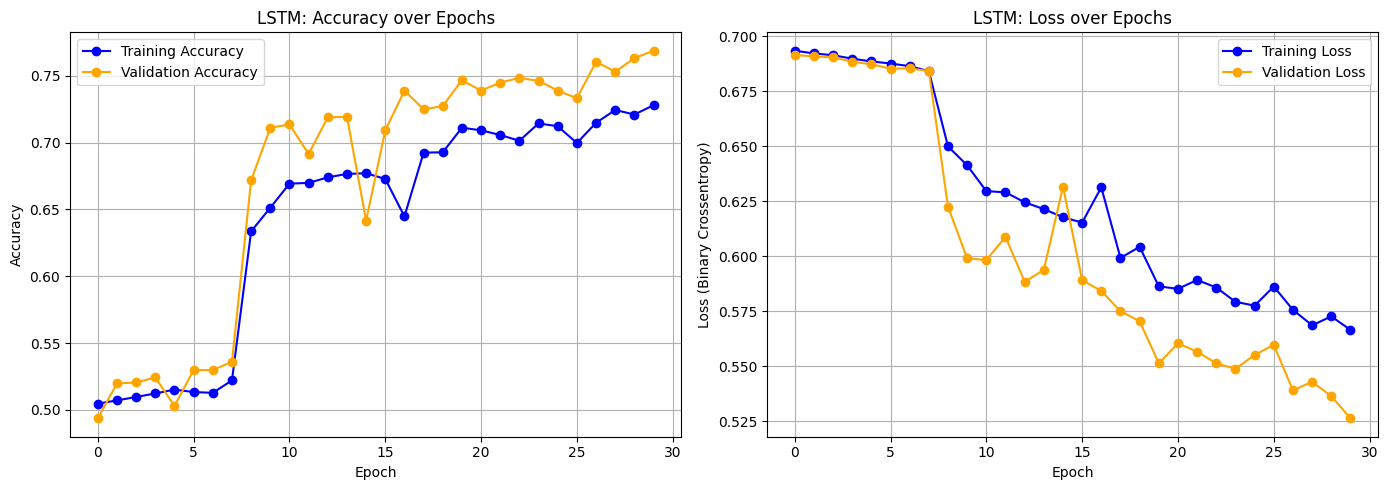

In [24]:
# Plot Accuracy and Loss over Epochs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
ax1.plot(model.history['accuracy'], label='Training Accuracy', color='blue', marker='o')
ax1.plot(model.history['val_accuracy'], label='Validation Accuracy', color='orange', marker='o')
ax1.set_title('LSTM: Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss Plot
ax2.plot(model.history['loss'], label='Training Loss', color='blue', marker='o')
ax2.plot(model.history['val_loss'], label='Validation Loss', color='orange', marker='o')
ax2.set_title('LSTM: Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss (Binary Crossentropy)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

**Making Predictions**

In [25]:
# Making predictions for the test data
y_test_pred = lstm_model.predict(X_test)

# Predicton comparison
y_test_pred = (y_test_pred >= 0.5).astype(int).ravel()
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_test_pred})
print("Actual vs Predicted labels:")
display(results.head())

156/156 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step
Actual vs Predicted labels:


,Actual,Predicted
0,1,1
1,0,1
2,1,0
3,1,1
4,0,0


# **Confusion Matrix**

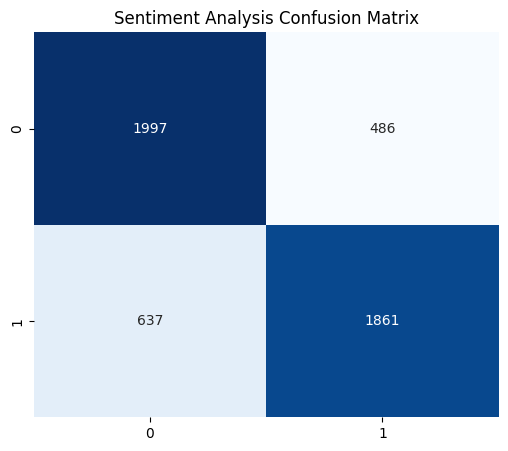

In [26]:
# Confusion Matrix for test set
cm = confusion_matrix(y_test, y_test_pred)

# Plotting the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='', cmap='Blues', cbar=False)
plt.title('Sentiment Analysis Confusion Matrix')
plt.show()

# **Full Model Evaluation**

In [27]:
# Accuracy on the testing set
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Testing Accuracy: {test_accuracy:.4f}")

# Precision score on the testing set
precision = precision_score(y_test, y_test_pred)
print(f"Test Precision Score: {precision:.4f}")

# Recall score on the testing set
recall = recall_score(y_test, y_test_pred)
print(f"Test Recall Score: {recall:.4f}")

# F1 score on the testing set
F1_score = f1_score(y_test, y_test_pred)
print(f"Test F1 Score: {F1_score:.4f}")

Testing Accuracy: 0.7745
Test Precision Score: 0.7929
Test Recall Score: 0.7450
Test F1 Score: 0.7682


In [28]:
# Classification Report
classification = classification_report(y_test, y_test_pred)
print(f"Classification report:\n {classification}")


Classification report:
               precision    recall  f1-score   support

           0       0.76      0.80      0.78      2483
           1       0.79      0.74      0.77      2498

    accuracy                           0.77      4981
   macro avg       0.78      0.77      0.77      4981
weighted avg       0.78      0.77      0.77      4981



# **Conclusion And Final Evaluation**

The LSTM model developed in this project achieved an overall test accuracy of **77.45%**, with a **precision of 79.29%**, **recall of 74.50%**, and **F1-score of 76.82%**.

The classification report shows relatively balanced performance across both sentiment classes. Class 0 achieved an F1-score of **0.78**, while Class 1 achieved an F1-score of **0.77**. This indicates that the model performs reasonably consistently when identifying both sentiment categories.

The confusion matrix shows that the model correctly classified **1,997 observations from Class 0** and **1,861 observations from Class 1**, while misclassifying **486 Class 0 observations** and **637 Class 1 observations**.

The dataset used for evaluation was also reasonably balanced, with **2,483 observations in Class 0** and **2,498 observations in Class 1**. Therefore, the accuracy score provides a meaningful overall indication of model performance rather than being strongly influenced by class imbalance.

The training and validation results show that the model was able to learn meaningful patterns from the text data, while the final test results demonstrate that these patterns generalized reasonably well to unseen data.

Overall, the LSTM model provides a **solid baseline sentiment classification system**, achieving approximately **77% accuracy** on unseen test data. While the model could potentially be improved through further hyperparameter tuning, preprocessing, embedding strategies, or alternative architectures, the current performance is sufficient for this project and provides a strong foundation for future development.

This project demonstrates the complete process of developing a text classification model, including text preprocessing, tokenization, sequence padding, LSTM model development, training, validation, and evaluation using multiple classification metrics.

# **Save the trained LSTM model and Tokenizer**

In [32]:
lstm_model.save("lstm_sentiment_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [33]:
from google.colab import files

files.download("lstm_sentiment_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Tokenizer saved successfully!")

Tokenizer saved successfully!


In [35]:
files.download("tokenizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>